# 2022 NHTS travel behaviour EDA

This notebook describes reported movements by identified household vehicles and saves presentation figures.
Source files are read without modification.

Official sources: 2022 NHTS User Guide (pp. 4, 24–26) and Public Use Codebook v2.0.1
(trip variables, pp. 34–47), both in data/raw/nhts_2022/docs/. See also
docs/methodology/nhts_variable_mapping.md.
Every TRIP row is a person trip. The User Guide defines a vehicle trip using a household
member who drove a privately operated vehicle.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

root = Path.cwd().resolve()
if not (root / "data" / "raw" / "nhts_2022").exists():
    root = root.parent
raw = root / "data" / "raw" / "nhts_2022"
figure_dir = root / "outputs" / "figures" / "travel_eda"
figure_dir.mkdir(parents=True, exist_ok=True)
trip = pd.read_csv(raw / "tripv2pub.csv", dtype="string", keep_default_na=False)
vehicle = pd.read_csv(raw / "vehv2pub.csv", dtype="string", keep_default_na=False)

plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.facecolor": "white"})
BLUE, ORANGE, GREEN, PURPLE = "#2463a6", "#dd7e27", "#287d69", "#7757a5"

def hhmm_minutes(series):
    text = series.astype("string")
    hour = pd.to_numeric(text.str[:2], errors="coerce")
    minute = pd.to_numeric(text.str[2:4], errors="coerce")
    valid = text.str.fullmatch(r"\d{4}").fillna(False) & hour.between(0, 23) & minute.between(0, 59)
    return (60 * hour + minute).where(valid).astype("Float64")

def clock(value):
    minute = int(value) % 1440
    return f"{minute // 60:02d}:{minute % 60:02d}"

def weighted_quantile(values, weights, q):
    x, w = np.asarray(values, float), np.asarray(weights, float)
    ok = np.isfinite(x) & np.isfinite(w) & (w > 0)
    x, w = x[ok], w[ok]
    order = np.argsort(x)
    return np.interp(q * w.sum(), np.cumsum(w[order]), x[order])

def percent_hist(values, weights, bins):
    return 100 * np.histogram(np.asarray(values, float), bins=bins,
                               weights=np.asarray(weights, float))[0] / np.asarray(weights, float).sum()

def format_time_axis(ax, step=120):
    ticks = np.arange(0, 1441, step)
    ax.set_xticks(ticks, [clock(x) if x < 1440 else "24:00" for x in ticks])
    ax.set_xlim(0, 1440)
    ax.grid(axis="y", color="#dddddd", linewidth=.6)

def save_show(fig, filename):
    fig.tight_layout()
    output = figure_dir / filename
    fig.savefig(output, dpi=190, bbox_inches="tight")
    plt.show()
    return output


## 1. Analysis population and conflict rule

The User Guide (p. 26) specifies driver flag 01 and privately operated vehicle mode codes
01, 02, 03, 04, 06, and 07. Here we also require household vehicle use (TRPHHVEH=01)
and an identified roster vehicle. We retain the full candidate table in memory for audit.

For the main figures, times must be valid HHMM, duration must agree with clock time modulo
24 hours, and distance must be nonnegative. We hold out whole vehicle-days where the same
vehicle has two driver records starting at the same minute or overlapping driver intervals.
We do not choose one of two competing driver reports or deduplicate either one.


In [2]:
POV_MODES = {"01", "02", "03", "04", "06", "07"}
household_vehicle = trip.loc[trip.TRPHHVEH.eq("01")].copy()
all_drivers = trip.loc[trip.DRVR_FLG.eq("01")].copy()
household_driver = household_vehicle.loc[household_vehicle.DRVR_FLG.eq("01")].copy()
candidate = household_driver.loc[
    household_driver.VEHCASEID.ne("-1") &
    household_driver.VEHCASEID.isin(vehicle.VEHCASEID) &
    household_driver.TRPTRANS.isin(POV_MODES)
].copy()
candidate["start_min"] = hhmm_minutes(candidate.STRTTIME)
candidate["end_min"] = hhmm_minutes(candidate.ENDTIME)
for col in ["TRVLCMIN", "TRPMILES", "DWELTIME", "WTTRDFIN", "WTTRDFIN5D", "WTTRDFIN2D"]:
    candidate[col + "_num"] = pd.to_numeric(candidate[col], errors="coerce")
candidate["crosses_midnight"] = candidate.end_min < candidate.start_min
candidate["clock_duration"] = (candidate.end_min - candidate.start_min) % 1440
candidate["valid_measures"] = (
    candidate.start_min.notna() & candidate.end_min.notna() &
    candidate.TRVLCMIN_num.ge(0) & candidate.TRPMILES_num.ge(0) &
    candidate.clock_duration.eq(candidate.TRVLCMIN_num)
)
valid = candidate.loc[candidate.valid_measures.fillna(False)].copy()
# NHTS travel day is 04:00 to 04:00 next day; shift 00:00–03:59 to the end.
valid["survey_start_min"] = valid.start_min.where(valid.start_min >= 240, valid.start_min + 1440)
valid["survey_end_min"] = valid.survey_start_min + valid.TRVLCMIN_num
start_size = valid.groupby(["VEHCASEID", "STRTTIME"]).TDCASEID.transform("size")
same_start = valid.loc[start_size > 1]
same_start_ids = set(same_start.VEHCASEID)
unique_start = valid.loc[~valid.VEHCASEID.isin(same_start_ids)].copy()
unique_start = unique_start.sort_values(["VEHCASEID", "survey_start_min", "survey_end_min"])
running_end = unique_start.groupby("VEHCASEID").survey_end_min.cummax()
unique_start["prior_end"] = running_end.groupby(unique_start.VEHCASEID).shift()
overlap = unique_start.loc[unique_start.survey_start_min < unique_start.prior_end]
overlap_ids = set(overlap.VEHCASEID)
conflict_ids = same_start_ids | overlap_ids
analysis = valid.loc[~valid.VEHCASEID.isin(conflict_ids)].copy()
analysis = analysis.sort_values(["VEHCASEID", "survey_start_min", "survey_end_min"])
exact_pairs = valid.groupby(["VEHCASEID", "STRTTIME", "ENDTIME", "TRPMILES"]).size()

flow = pd.DataFrame([
    ("All TRIP person-trip rows", len(trip), "all person trips"),
    ("Household-vehicle person trips", len(household_vehicle), "TRPHHVEH=01"),
    ("Driver person trips, all vehicles", len(all_drivers), "DRVR_FLG=01"),
    ("Household-vehicle driver trips", len(household_driver), "both conditions"),
    ("Rows with valid roster vehicle ID", int((household_driver.VEHCASEID.ne("-1") & household_driver.VEHCASEID.isin(vehicle.VEHCASEID)).sum()), "matched to Vehicle file"),
    ("Documented privately operated vehicle modes", len(candidate), "candidate driver trips"),
    ("Valid clock, duration, distance", len(valid), "invalid records held in candidate"),
    ("After deduplication", len(valid), "none performed"),
    ("Conflict-free trips for main EDA", len(analysis), "conflicted vehicle-days held for audit"),
], columns=["Stage", "Rows", "Decision"])
display(flow)
display(pd.Series({
    "candidate vehicles": candidate.VEHCASEID.nunique(),
    "valid-measurement vehicles": valid.VEHCASEID.nunique(),
    "same-start pairs": len(same_start)//2,
    "same-start rows": len(same_start),
    "same-start vehicles": len(same_start_ids),
    "same vehicle/start/end/distance pairs": int((exact_pairs > 1).sum()),
    "other overlapping vehicles": len(overlap_ids),
    "conflicted vehicle-days held": len(conflict_ids),
    "final unique vehicles": analysis.VEHCASEID.nunique(),
}, name="Diagnostic count"))


,Stage,Rows,Decision
0,All TRIP person-trip rows,31074,all person trips
1,Household-vehicle person trips,26294,TRPHHVEH=01
2,"Driver person trips, all vehicles",20490,DRVR_FLG=01
3,Household-vehicle driver trips,20067,both conditions
4,Rows with valid roster vehicle ID,20067,matched to Vehicle file
5,Documented privately operated vehicle modes,20067,candidate driver trips
6,"Valid clock, duration, distance",20058,invalid records held in candidate
7,After deduplication,20058,none performed
8,Conflict-free trips for main EDA,19673,conflicted vehicle-days held for audit


candidate vehicles                       6943
valid-measurement vehicles               6943
same-start pairs                           92
same-start rows                           184
same-start vehicles                        59
same vehicle/start/end/distance pairs      57
other overlapping vehicles                 10
conflicted vehicle-days held               69
final unique vehicles                    6874
Name: Diagnostic count, dtype: int64

Among the same-start pairs, 57 pairs share vehicle, start, end, and distance; every such
pair involves two different persons marked as drivers. Other pairs disagree on end time,
distance, or purpose. Their trip weights may also differ. Exact vehicle-movement
deduplication is therefore not justified. The plotted subset is called conflict-free
candidate driver trips, not a proven census of physical vehicle movements.


## 2. Time parsing and midnight crossings

STRTTIME and ENDTIME are local 24-hour HHMM clock times (codebook pp. 41 and 35).
The User Guide sets the travel day at 04:00–04:00. An end clock time earlier than the
start is consistent with a midnight crossing when the modulo-24-hour clock gap matches
TRVLCMIN. This does not prove an exact date or rule out a data-quality issue for very long
trips. Such trips remain in the analysis.


In [3]:
crossing = valid.loc[valid.crosses_midnight.fillna(False)]
display(pd.Series({
    "candidate rows with invalid/missing start or end": int((candidate.start_min.isna() | candidate.end_min.isna()).sum()),
    "valid midnight crossings": len(crossing),
    "midnight crossings matching reported duration": int(crossing.clock_duration.eq(crossing.TRVLCMIN_num).sum()),
    "duration-consistent crossings at least 4 hours": int(crossing.TRVLCMIN_num.ge(240).sum()),
    "longest duration-consistent crossing (minutes)": int(crossing.TRVLCMIN_num.max()),
    "valid trips ending after 04:00 next day": int((valid.survey_end_min > 1680).sum()),
}, name="Time check"))
analysis["start_hour"] = (analysis.start_min // 60).astype(int)
analysis["end_hour"] = (analysis.end_min // 60).astype(int)
display(analysis[["STRTTIME", "ENDTIME", "start_min", "end_min",
                  "start_hour", "end_hour", "survey_start_min", "survey_end_min"]].head())
display(crossing.sort_values("TRVLCMIN_num", ascending=False)[
    ["STRTTIME", "ENDTIME", "TRVLCMIN", "TRPMILES"]
].head(5))
display(Markdown(
    f"All **{len(crossing)}** earlier-end records match their reported duration modulo 24 hours. "
    f"However, **{int(crossing.TRVLCMIN_num.ge(240).sum())}** last at least four hours "
    f"(longest **{int(crossing.TRVLCMIN_num.max())} minutes**). They are consistent with "
    "cross-midnight travel, while the unusually long cases still need review because the public "
    "file does not supply an exact trip date."
))


candidate rows with invalid/missing start or end       6
valid midnight crossings                              31
midnight crossings matching reported duration         31
duration-consistent crossings at least 4 hours        12
longest duration-consistent crossing (minutes)      1425
valid trips ending after 04:00 next day                3
Name: Time check, dtype: int64

,STRTTIME,ENDTIME,start_min,end_min,start_hour,end_hour,survey_start_min,survey_end_min
0,1435,1450,875.0,890.0,14,14,875.0,890.0
1,1605,1615,965.0,975.0,16,16,965.0,975.0
2,0700,0730,420.0,450.0,7,7,420.0,450.0
3,0740,0750,460.0,470.0,7,7,460.0,470.0
4,0800,0830,480.0,510.0,8,8,480.0,510.0


,STRTTIME,ENDTIME,TRVLCMIN,TRPMILES
15980,0800,0745,1425,8.17650714729646
5197,1420,1200,1300,11.6867619639528
19374,1110,0300,950,553.431945307644
14479,1000,0015,855,586.334990677439
14478,1000,0015,855,586.334990677439


All **31** earlier-end records match their reported duration modulo 24 hours. However, **12** last at least four hours (longest **1425 minutes**). They are consistent with cross-midnight travel, while the unusually long cases still need review because the public file does not supply an exact trip date.

## 3. Documented destination codes and survey weights

Destination is the reason for travel to the destination (WHYTO; codebook pp. 46–47).
Codes 01 and 02 are physically at home; 03 is work at a non-home location; 04–05
are other work-related activities. The regrouping below is explicit and leaves all
remaining codes under their official labels in the lookup.

The User Guide §7.2 recommends WTTRDFIN for seven-day annual trip and mileage estimates,
WTTRDFIN5D for weekdays, and WTTRDFIN2D for weekends. Weighted percentages below describe
trips in this defined subset. Raw vehicle-day results are sample descriptions.


In [4]:
WHYTO_LABELS = {
    "01":"Regular activities at home", "02":"Work from home (paid)",
    "03":"Work at a non-home location",
    "04":"Work activity to drop off/pick up someone or something",
    "05":"Other work-related activities", "06":"Attend school as a student",
    "07":"Attend childcare or adult care", "08":"Volunteer activities",
    "09":"Change type of transportation", "10":"Drop off/pick up someone (personal)",
    "11":"Health care visit", "12":"Buy meals",
    "13":"Shop/buy/pick up or return goods", "14":"Other family/personal errands",
    "15":"Recreational activities", "16":"Exercise", "17":"Visit friends or relatives",
    "18":"Rest or relaxation/vacation", "19":"Religious or other community activities",
    "97":"Something else (specify)",
}
def destination_group(code):
    if code in {"01","02"}: return "Home"
    if code == "03": return "Work"
    if code in {"04","05"}: return "Work-related other"
    if code in {"13","14"}: return "Shopping/errands"
    if code in {"15","16","17","18"}: return "Social/recreation"
    return "Other"

assert set(analysis.WHYTO).issubset(WHYTO_LABELS)
analysis["destination"] = analysis.WHYTO.map(destination_group)
analysis["weight_7d"] = analysis.WTTRDFIN_num.astype(float)
assert analysis.weight_7d.gt(0).all()
dest_order = ["Home", "Work", "Shopping/errands", "Social/recreation",
              "Work-related other", "Other"]
destination_share = (100 * analysis.groupby("destination").weight_7d.sum()
                     / analysis.weight_7d.sum()).reindex(dest_order)
display(pd.DataFrame({
    "raw candidate trips": analysis.destination.value_counts().reindex(dest_order),
    "seven-day weighted share (%)": destination_share.round(1),
}))


,raw candidate trips,seven-day weighted share (%)
destination,,
Home,7749,39.5
Work,2388,13.9
Shopping/errands,3535,16.4
Social/recreation,1716,8.2
Work-related other,452,2.5
Other,3833,19.5


## 4. Departure and arrival times

Thirty-minute bins show the seven-day weighted share of trips. Arrivals after midnight
appear at their local clock hour; chronology is retained separately for vehicle-day summaries.


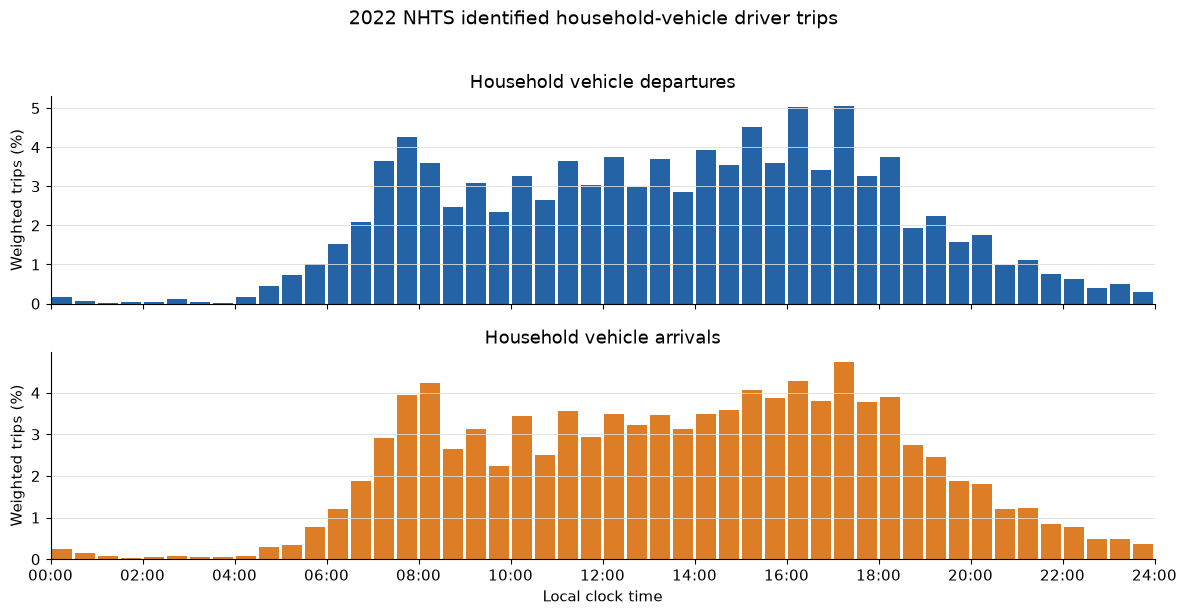

- Largest departure bin: **17:00–17:30**, **5.1%** of weighted trips.
- Largest arrival bin: **17:00–17:30**, **4.7%**. These are travel peaks only.

In [5]:
bins30 = np.arange(0, 1441, 30)
centers30 = bins30[:-1] + 15
departure_pct = percent_hist(analysis.start_min, analysis.weight_7d, bins30)
arrival_pct = percent_hist(analysis.end_min, analysis.weight_7d, bins30)
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].bar(centers30, departure_pct, width=27, color=BLUE)
axes[1].bar(centers30, arrival_pct, width=27, color=ORANGE)
axes[0].set(title="Household vehicle departures", ylabel="Weighted trips (%)")
axes[1].set(title="Household vehicle arrivals", ylabel="Weighted trips (%)", xlabel="Local clock time")
for ax in axes: format_time_axis(ax)
fig.suptitle("2022 NHTS identified household-vehicle driver trips", fontsize=14, y=1.02)
fig_time = save_show(fig, "01_departure_arrival_times.png")
dep_peak, arr_peak = int(np.argmax(departure_pct)), int(np.argmax(arrival_pct))
display(Markdown(
    f"- Largest departure bin: **{clock(bins30[dep_peak])}–{clock(bins30[dep_peak+1])}**, "
    f"**{departure_pct[dep_peak]:.1f}%** of weighted trips.\n"
    f"- Largest arrival bin: **{clock(bins30[arr_peak])}–{clock(bins30[arr_peak+1])}**, "
    f"**{arrival_pct[arr_peak]:.1f}%**. These are travel peaks only."
))


## 5. Trip distance and duration

Statistics retain all valid trips. Histograms stop at the raw-sample 99th percentile
solely for display; values beyond the right edge remain in the statistics and are counted.
NHTS TRPMILES is calculated miles; TRVLCMIN is minutes.


,sample count,raw mean,raw p25,raw median,raw p75,raw p90,raw p95,raw p99,raw max,weighted mean,weighted median,weighted p90
Distance (miles),19673.0,11.12,2.14,4.89,11.1,22.01,33.63,92.56,1123.57,11.00,5.21,23.37
Duration (minutes),19673.0,22.56,10.00,15.00,28.0,40.00,60.00,120.00,1425.00,22.86,15.00,45.00


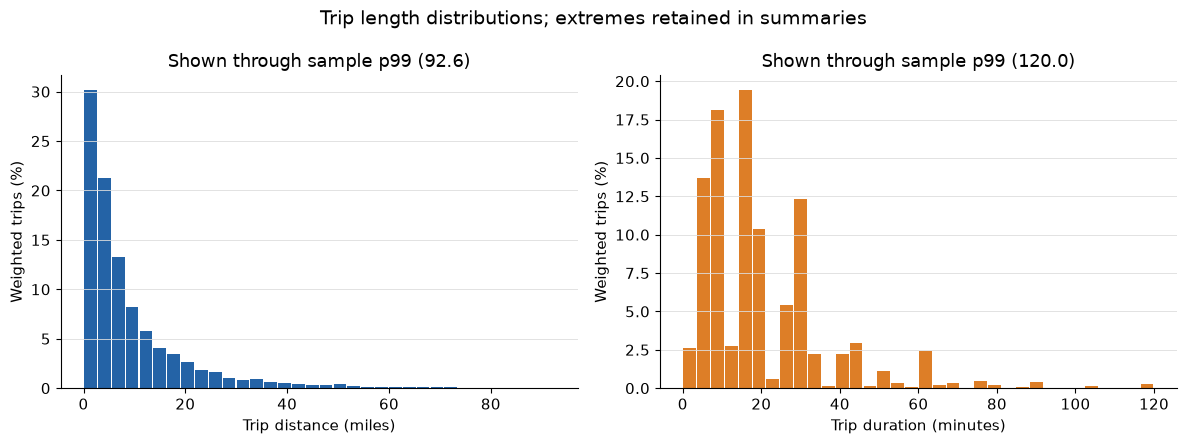

- Weighted median distance is **5.2 miles**; **197** trips exceed the distance display limit.
- Weighted median duration is **15 minutes**; **181** trips exceed the duration display limit.

In [6]:
def trip_stats(column):
    x, w = analysis[column].astype(float), analysis.weight_7d
    return pd.Series({
        "sample count":len(x), "raw mean":x.mean(), "raw p25":x.quantile(.25),
        "raw median":x.median(), "raw p75":x.quantile(.75),
        "raw p90":x.quantile(.9), "raw p95":x.quantile(.95),
        "raw p99":x.quantile(.99), "raw max":x.max(),
        "weighted mean":np.average(x, weights=w),
        "weighted median":weighted_quantile(x,w,.5),
        "weighted p90":weighted_quantile(x,w,.9),
    })
distance_stats = trip_stats("TRPMILES_num")
duration_stats = trip_stats("TRVLCMIN_num")
display(pd.DataFrame({"Distance (miles)":distance_stats,
                      "Duration (minutes)":duration_stats}).T.round(2))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col, stats, color, xlabel in [
    (axes[0],"TRPMILES_num",distance_stats,BLUE,"Trip distance (miles)"),
    (axes[1],"TRVLCMIN_num",duration_stats,ORANGE,"Trip duration (minutes)"),
]:
    limit = float(stats["raw p99"])
    edges = np.linspace(0, limit, 35)
    pct = percent_hist(analysis[col], analysis.weight_7d, edges)
    ax.bar((edges[:-1]+edges[1:])/2, pct, width=np.diff(edges)*.92, color=color)
    ax.set(xlabel=xlabel, ylabel="Weighted trips (%)",
           title=f"Shown through sample p99 ({limit:.1f})")
    ax.grid(axis="y", color="#dddddd", linewidth=.6)
fig.suptitle("Trip length distributions; extremes retained in summaries", fontsize=14)
fig_length = save_show(fig, "02_distance_duration.png")
distance_above = int((analysis.TRPMILES_num > distance_stats["raw p99"]).sum())
duration_above = int((analysis.TRVLCMIN_num > duration_stats["raw p99"]).sum())
display(Markdown(
    f"- Weighted median distance is **{distance_stats['weighted median']:.1f} miles**; "
    f"**{distance_above}** trips exceed the distance display limit.\n"
    f"- Weighted median duration is **{duration_stats['weighted median']:.0f} minutes**; "
    f"**{duration_above}** trips exceed the duration display limit."
))


## 6. Destination purpose and arrival time

The bar chart shows weighted destination shares. The arrival curves are normalized within
each destination group, so their heights show timing rather than the groups' sizes.


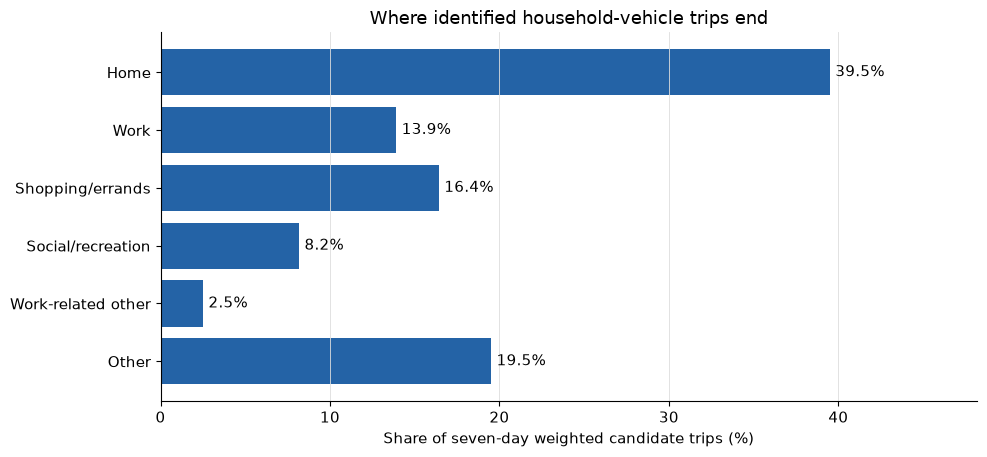

- **Home** accounts for **39.5%** and non-home **Work** for **13.9%** of weighted candidate trips.
- **Shopping/errands** accounts for **16.4%**. Purpose identifies an activity destination, not a measured parking or charging event.

In [7]:
fig, ax = plt.subplots(figsize=(10,4.7))
reverse = dest_order[::-1]
bars = ax.barh(reverse, destination_share.reindex(reverse), color=BLUE)
ax.bar_label(bars, labels=[f"{x:.1f}%" for x in destination_share.reindex(reverse)], padding=4)
ax.set(title="Where identified household-vehicle trips end",
       xlabel="Share of seven-day weighted candidate trips (%)")
ax.set_xlim(0, destination_share.max()*1.22)
ax.grid(axis="x", color="#dddddd", linewidth=.6)
fig_purpose = save_show(fig, "03_destination_purpose.png")
display(Markdown(
    f"- **Home** accounts for **{destination_share['Home']:.1f}%** and non-home **Work** "
    f"for **{destination_share['Work']:.1f}%** of weighted candidate trips.\n"
    f"- **Shopping/errands** accounts for **{destination_share['Shopping/errands']:.1f}%**. "
    "Purpose identifies an activity destination, not a measured parking or charging event."
))


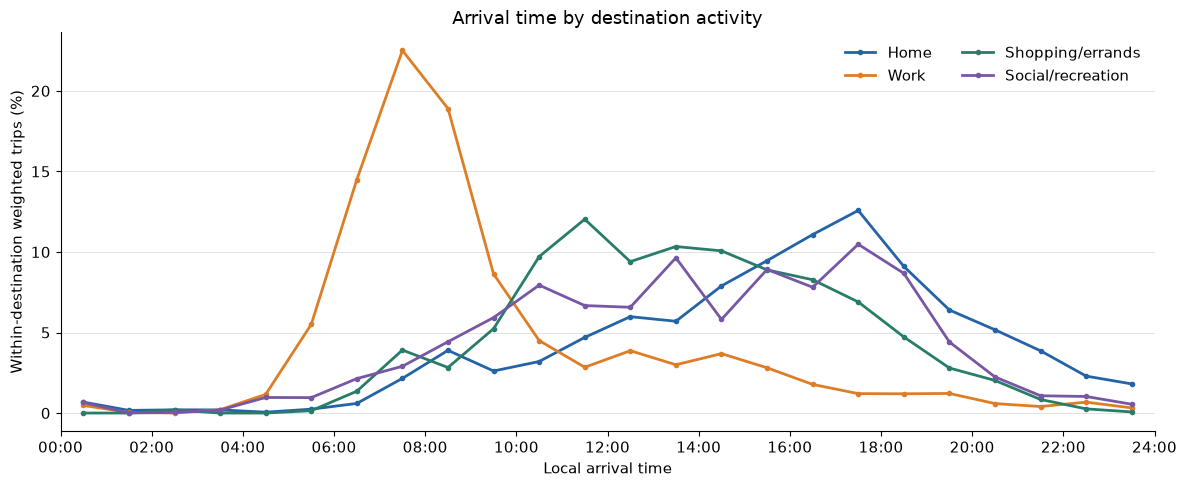

- Home arrivals peak at **17:00–18:00** (**12.6%** of weighted home-bound trips).
- Non-home work arrivals peak at **07:00–08:00** (**22.5%** of weighted work-bound trips).

In [8]:
bins60 = np.arange(0,1441,60)
centers60 = bins60[:-1]+30
arrival_groups = ["Home","Work","Shopping/errands","Social/recreation"]
arrival_peaks = {}
fig, ax = plt.subplots(figsize=(12,5))
for group,color in zip(arrival_groups,[BLUE,ORANGE,GREEN,PURPLE]):
    subset = analysis.loc[analysis.destination.eq(group)]
    pct = percent_hist(subset.end_min,subset.weight_7d,bins60)
    ax.plot(centers60,pct,marker="o",markersize=3,linewidth=2,label=group,color=color)
    arrival_peaks[group] = (int(np.argmax(pct)),float(np.max(pct)))
format_time_axis(ax)
ax.set(title="Arrival time by destination activity",xlabel="Local arrival time",
       ylabel="Within-destination weighted trips (%)")
ax.legend(ncol=2,frameon=False)
fig_arrival_purpose = save_show(fig, "04_arrival_by_destination.png")
hp,wp = arrival_peaks["Home"][0],arrival_peaks["Work"][0]
display(Markdown(
    f"- Home arrivals peak at **{clock(bins60[hp])}–{clock(bins60[hp+1])}** "
    f"(**{arrival_peaks['Home'][1]:.1f}%** of weighted home-bound trips).\n"
    f"- Non-home work arrivals peak at **{clock(bins60[wp])}–{clock(bins60[wp+1])}** "
    f"(**{arrival_peaks['Work'][1]:.1f}%** of weighted work-bound trips)."
))


## 7. Weekday versus weekend

Weekday estimates use the official five-day trip weight; weekend estimates use the
two-day trip weight. The timing and destination curves are normalized within day type.


,sample trips,weighted median departure,weighted median miles,weighted p90 miles,weighted home arrivals (%),weighted work arrivals (%)
Weekday,14720,13:00,5.3,22.4,38.9,17.3
Weekend,4953,14:00,4.9,26.8,39.5,5.9


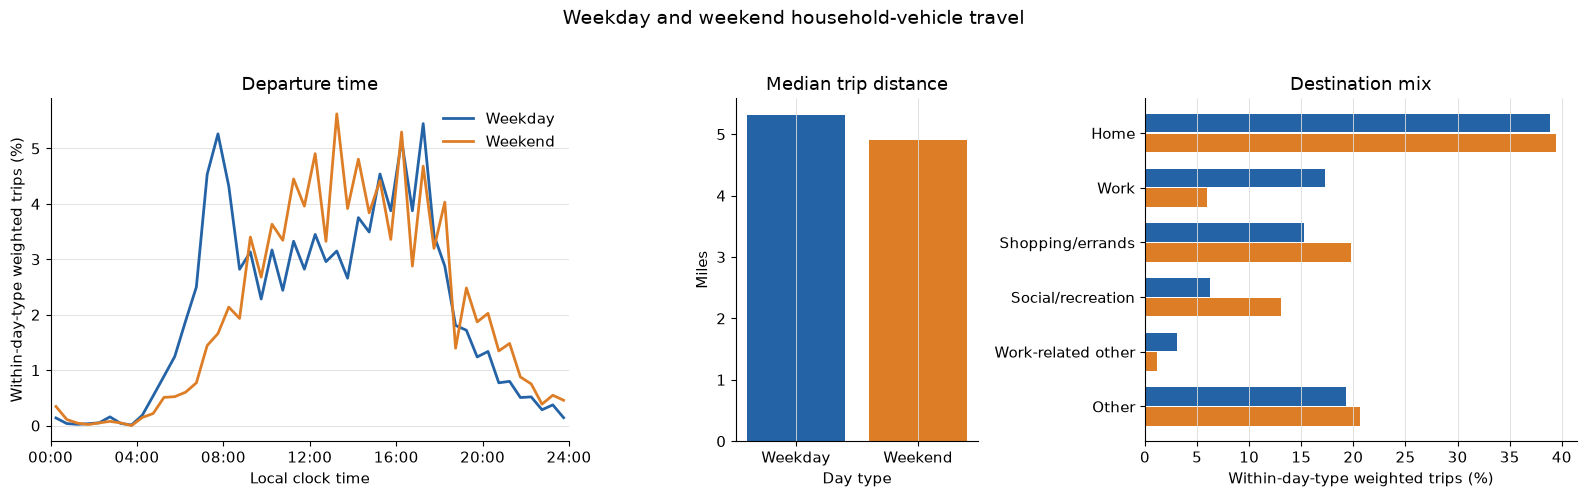

- Median departure is **13:00** on weekdays and **14:00** on weekends.
- Median trip distance is **5.3** versus **4.9 miles**; work-bound shares are **17.3%** and **5.9%**, respectively.

In [9]:
day_spec = {"Weekday":("02","WTTRDFIN5D_num",BLUE),
            "Weekend":("01","WTTRDFIN2D_num",ORANGE)}
days = {}
for label,(code,weight_col,color) in day_spec.items():
    sub = analysis.loc[analysis.TDWKND.eq(code)].copy()
    w = sub[weight_col].astype(float)
    days[label] = {
        "data":sub,"weight":w,"color":color,
        "departure":percent_hist(sub.start_min,w,bins30),
        "median_departure":weighted_quantile(sub.start_min,w,.5),
        "median_miles":weighted_quantile(sub.TRPMILES_num,w,.5),
        "p90_miles":weighted_quantile(sub.TRPMILES_num,w,.9),
        "purpose":(100*sub.groupby("destination")[weight_col].sum()/w.sum()).reindex(dest_order,fill_value=0),
    }
display(pd.DataFrame({
    name:pd.Series({
        "sample trips":len(d["data"]),
        "weighted median departure":clock(d["median_departure"]),
        "weighted median miles":round(d["median_miles"],1),
        "weighted p90 miles":round(d["p90_miles"],1),
        "weighted home arrivals (%)":round(d["purpose"]["Home"],1),
        "weighted work arrivals (%)":round(d["purpose"]["Work"],1),
    }) for name,d in days.items()
}).T)
fig,axes = plt.subplots(1,3,figsize=(16,4.8),gridspec_kw={"width_ratios":[1.5,.7,1.25]})
for label,d in days.items():
    axes[0].plot(centers30,d["departure"],color=d["color"],label=label,linewidth=2)
format_time_axis(axes[0], step=240)
axes[0].set(title="Departure time",xlabel="Local clock time",ylabel="Within-day-type weighted trips (%)")
axes[0].legend(frameon=False)
labels = list(days)
axes[1].bar(np.arange(2),[days[k]["median_miles"] for k in labels],color=[BLUE,ORANGE])
axes[1].set(title="Median trip distance",xlabel="Day type",ylabel="Miles",
            xticks=np.arange(2),xticklabels=labels)
y = np.arange(len(dest_order))
for i,label in enumerate(labels):
    axes[2].barh(y+(i-.5)*.36,days[label]["purpose"],height=.34,
                 color=days[label]["color"],label=label)
axes[2].set(title="Destination mix",xlabel="Within-day-type weighted trips (%)",
            yticks=y,yticklabels=dest_order)
axes[2].invert_yaxis()
for ax in axes[1:]: ax.grid(axis="x",color="#dddddd",linewidth=.6)
fig.suptitle("Weekday and weekend household-vehicle travel",fontsize=14,y=1.03)
fig_daytype = save_show(fig,"05_weekday_weekend.png")
display(Markdown(
    f"- Median departure is **{clock(days['Weekday']['median_departure'])}** on weekdays "
    f"and **{clock(days['Weekend']['median_departure'])}** on weekends.\n"
    f"- Median trip distance is **{days['Weekday']['median_miles']:.1f}** versus "
    f"**{days['Weekend']['median_miles']:.1f} miles**; work-bound shares are "
    f"**{days['Weekday']['purpose']['Work']:.1f}%** and "
    f"**{days['Weekend']['purpose']['Work']:.1f}%**, respectively."
))


## 8. Observed vehicle-day behaviour

These are raw sample summaries among vehicles with reported conflict-free driver trips.
Observed daily miles sum only the recorded trip legs. Trips before 04:00 are placed at
the end of the assigned survey day. TDAYDATE is YYYYMM, not a full calendar date.
No date is invented. The figure is not a weighted estimate for all US vehicles.


,trips,observed_miles,first_departure,last_arrival
count,6874.0,6874.0,6874.0,6874.0
mean,2.9,31.8,629.4,978.6
std,1.6,59.9,219.2,222.1
min,1.0,0.0,240.0,247.0
25%,2.0,7.4,460.0,839.2
50%,2.0,16.6,580.0,996.0
75%,4.0,35.3,780.0,1120.0
90%,5.0,65.3,960.0,1260.0
95%,6.0,97.4,1060.0,1325.0
max,22.0,1123.6,1440.0,2172.0


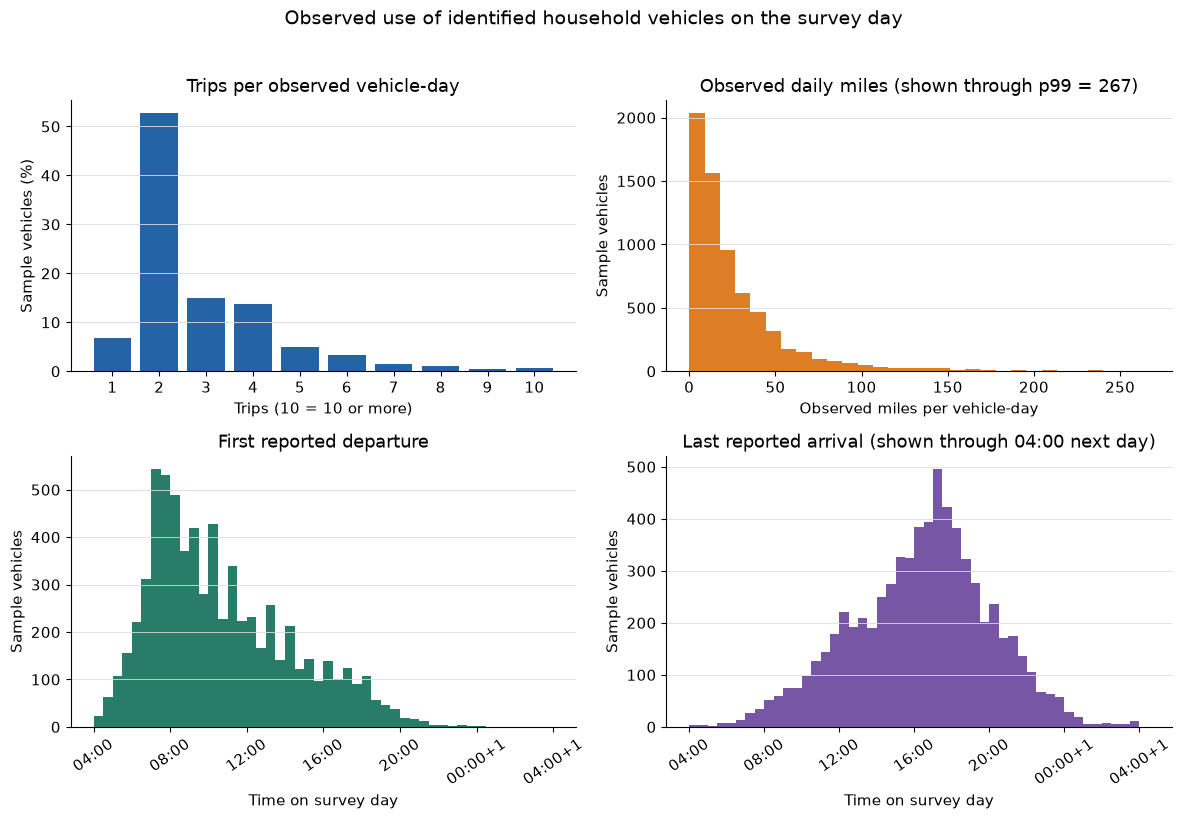

- Among **6,874** observed vehicles, raw medians are **2 trips** and **16.6 miles**.
- Median first departure is **09:40**; median last arrival is **16:36** (clock time shown after accounting for the 04:00 day boundary). 2 later arrivals fall beyond the figure's displayed interval; they remain in the summaries.

In [10]:
vehicle_day = analysis.groupby("VEHCASEID").agg(
    trips=("TDCASEID","size"),observed_miles=("TRPMILES_num","sum"),
    first_departure=("survey_start_min","min"),last_arrival=("survey_end_min","max"))
display(vehicle_day.describe(percentiles=[.25,.5,.75,.9,.95]).round(1))
fig,axes = plt.subplots(2,2,figsize=(12,8))
trip_bins = np.arange(1,11)
counts = vehicle_day.trips.clip(upper=10).value_counts().reindex(trip_bins,fill_value=0)
axes[0,0].bar(trip_bins,100*counts/len(vehicle_day),color=BLUE)
axes[0,0].set(title="Trips per observed vehicle-day",xlabel="Trips (10 = 10 or more)",
              ylabel="Sample vehicles (%)",xticks=trip_bins)
daily_p99 = float(vehicle_day.observed_miles.quantile(.99))
axes[0,1].hist(vehicle_day.observed_miles.astype(float),
               bins=np.linspace(0,daily_p99,31),color=ORANGE)
axes[0,1].set(title=f"Observed daily miles (shown through p99 = {daily_p99:.0f})",
              xlabel="Observed miles per vehicle-day",ylabel="Sample vehicles")
survey_ticks = [240,480,720,960,1200,1440,1680]
survey_labels = ["04:00","08:00","12:00","16:00","20:00","00:00+1","04:00+1"]
axes[1,0].hist(vehicle_day.first_departure.astype(float),
               bins=np.arange(240,1681,30),color=GREEN)
axes[1,0].set(title="First reported departure",xlabel="Time on survey day",
              ylabel="Sample vehicles",xticks=survey_ticks,xticklabels=survey_labels)
last_limit = max(1680,int(np.ceil(float(vehicle_day.last_arrival.quantile(.995))/30)*30))
axes[1,1].hist(vehicle_day.last_arrival.astype(float),
               bins=np.arange(240,last_limit+31,30),color=PURPLE)
axes[1,1].set(title="Last reported arrival (shown through 04:00 next day)",xlabel="Time on survey day",
              ylabel="Sample vehicles",xticks=survey_ticks,xticklabels=survey_labels)
for ax in axes.flat:
    ax.grid(axis="y",color="#dddddd",linewidth=.6)
for ax in axes[1,:]: ax.tick_params(axis="x",labelrotation=35)
fig.suptitle("Observed use of identified household vehicles on the survey day",fontsize=14,y=1.02)
fig_vehicle_day = save_show(fig,"06_vehicle_day_summary.png")
last_arrival_beyond_display = int((vehicle_day.last_arrival > 1680).sum())
display(Markdown(
    f"- Among **{len(vehicle_day):,}** observed vehicles, raw medians are "
    f"**{vehicle_day.trips.median():.0f} trips** and **{vehicle_day.observed_miles.median():.1f} miles**.\n"
    f"- Median first departure is **{clock(vehicle_day.first_departure.median())}**; "
    f"median last arrival is **{clock(vehicle_day.last_arrival.median())}** "
    f"(clock time shown after accounting for the 04:00 day boundary). "
    f"{last_arrival_beyond_display} later arrivals fall beyond the figure's displayed interval; "
    "they remain in the summaries."
))


## 9. Destination dwell and parking limits

The codebook labels DWELTIME as “Time at Destination (minutes)” for a person trip.
Its -9 code is “not ascertained.” It is not a direct vehicle parking measurement.
Coverage is especially uneven for home destinations, where the last home trip often
has no later departure in the reported day. A vehicle parking window requires verified
same-vehicle location continuity, complete movements, and treatment of the day boundary.


,all sample trips,recorded dwell,coverage (%),median recorded minutes,p90 recorded minutes
Destination,,,,,
Home,7749,1694,21.9,125.0,420.0
Work,2388,2277,95.4,490.0,620.0
Shopping/errands,3535,3459,97.9,30.0,85.0
Social/recreation,1716,1588,92.5,110.0,270.0


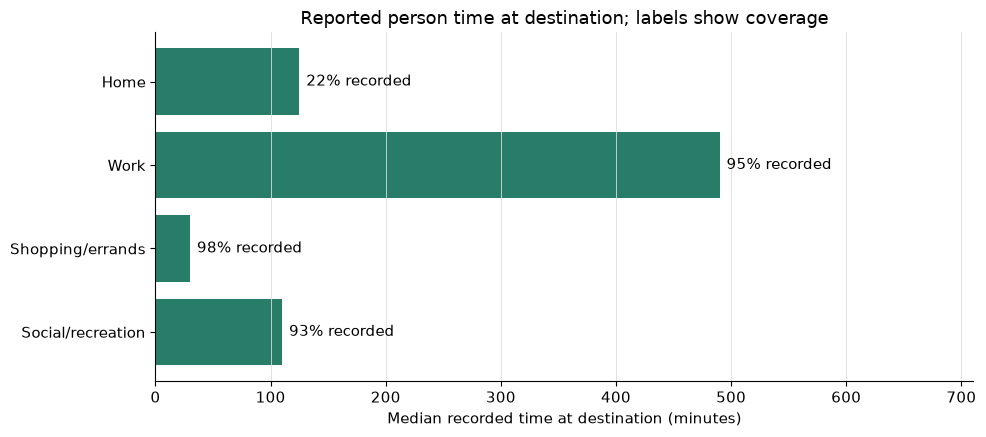

- Work destination dwell has an observed sample median of **490 minutes** with **95%** coverage.
- Home dwell is recorded for only **22%** of home-bound trips. These durations are person destination intervals, not measured vehicle parking.

In [11]:
analysis["dwell_valid"] = analysis.DWELTIME_num.where(analysis.DWELTIME_num >= 0)
dwell_rows = []
for group in ["Home","Work","Shopping/errands","Social/recreation"]:
    sub = analysis.loc[analysis.destination.eq(group)]
    observed = sub.dwell_valid.dropna().astype(float)
    dwell_rows.append({
        "Destination":group,"all sample trips":len(sub),"recorded dwell":len(observed),
        "coverage (%)":100*len(observed)/len(sub),
        "median recorded minutes":observed.median(),
        "p90 recorded minutes":observed.quantile(.9),
    })
dwell = pd.DataFrame(dwell_rows).set_index("Destination")
display(dwell.round(1))
fig,ax = plt.subplots(figsize=(10,4.5))
order = list(dwell.index[::-1])
bars = ax.barh(order,dwell.loc[order,"median recorded minutes"],color=GREEN)
ax.bar_label(bars,labels=[f"{dwell.loc[k,'coverage (%)']:.0f}% recorded" for k in order],padding=5)
ax.set(title="Reported person time at destination; labels show coverage",
       xlabel="Median recorded time at destination (minutes)")
ax.set_xlim(0,dwell["median recorded minutes"].max()*1.45)
ax.grid(axis="x",color="#dddddd",linewidth=.6)
fig_dwell = save_show(fig,"07_destination_dwell_coverage.png")
display(Markdown(
    f"- Work destination dwell has an observed sample median of "
    f"**{dwell.loc['Work','median recorded minutes']:.0f} minutes** with "
    f"**{dwell.loc['Work','coverage (%)']:.0f}%** coverage.\n"
    f"- Home dwell is recorded for only **{dwell.loc['Home','coverage (%)']:.0f}%** "
    "of home-bound trips. These durations are person destination intervals, not measured vehicle parking."
))


## 10. Example chronological vehicle trip chains

The examples are chosen deterministically from conflict-free vehicle-days with one
reported driver, 2–5 legs, home origin and return, activity continuity between legs,
non-overlapping times, and under 100 observed miles. For each requested pattern, the
selected day is closest to the median distance among eligible days of that pattern.
These tables illustrate records; they are not prevalence estimates.


In [12]:
def chain_is_coherent(g):
    g = g.sort_values("survey_start_min")
    if not 2 <= len(g) <= 5 or g.PERSONID.nunique() != 1:
        return False
    if g.iloc[0].WHYFROM not in {"01","02"} or g.iloc[-1].WHYTO not in {"01","02"}:
        return False
    if float(g.TRPMILES_num.sum()) >= 100:
        return False
    if not np.all(g.survey_start_min.iloc[1:].to_numpy(dtype=float)
                  >= g.survey_end_min.iloc[:-1].to_numpy(dtype=float)):
        return False
    return list(g.WHYTO.iloc[:-1]) == list(g.WHYFROM.iloc[1:])

chain_days = [g.sort_values("survey_start_min") for _,g in analysis.groupby("VEHCASEID")
              if chain_is_coherent(g)]
patterns = {
    "Home → Work → Home":lambda g: len(g)==2 and g.iloc[0].WHYTO=="03",
    "Home → Shopping/errands → Home":lambda g: len(g)==2 and g.iloc[0].WHYTO in {"13","14"},
    "Home → multiple destinations → Home":lambda g: len(g)>=3 and
        any(c in {"13","14"} for c in g.WHYTO.iloc[:-1]) and
        any(c=="03" for c in g.WHYTO.iloc[:-1]),
}
examples = {}
for label,criterion in patterns.items():
    choices = [g for g in chain_days if criterion(g)]
    if not choices: continue
    median_miles = np.median([float(g.TRPMILES_num.sum()) for g in choices])
    chosen = min(choices,key=lambda g:(abs(float(g.TRPMILES_num.sum())-median_miles),
                                      str(g.iloc[0].VEHCASEID)))
    examples[label] = chosen
    display(Markdown(f"**{label}** · vehicle {chosen.iloc[0].VEHCASEID} · "
                     f"{len(chosen)} legs · {float(chosen.TRPMILES_num.sum()):.1f} observed miles"))
    display(pd.DataFrame({
        "Departure":chosen.start_min.map(clock).to_numpy(),
        "Arrival":chosen.end_min.map(clock).to_numpy(),
        "Distance (miles)":chosen.TRPMILES_num.astype(float).round(1).to_numpy(),
        "Destination activity":chosen.WHYTO.map(WHYTO_LABELS).to_numpy(),
        "Recorded person dwell (min)":chosen.dwell_valid.to_numpy(),
    },index=np.arange(1,len(chosen)+1)).rename_axis("Leg"))
display(Markdown("Blank dwell values remain blank. No overnight parking duration is inferred."))


**Home → Work → Home** · vehicle 900020866102 · 2 legs · 20.1 observed miles

,Departure,Arrival,Distance (miles),Destination activity,Recorded person dwell (min)
Leg,,,,,
1,09:00,09:40,10.7,Work at a non-home location,380.0
2,16:00,16:50,9.5,Regular activities at home,NaN


**Home → Shopping/errands → Home** · vehicle 900009599401 · 2 legs · 7.0 observed miles

,Departure,Arrival,Distance (miles),Destination activity,Recorded person dwell (min)
Leg,,,,,
1,14:30,14:45,3.5,Other family/personal errands,30.0
2,15:15,15:30,3.5,Regular activities at home,NaN


**Home → multiple destinations → Home** · vehicle 900005795901 · 3 legs · 24.4 observed miles

,Departure,Arrival,Distance (miles),Destination activity,Recorded person dwell (min)
Leg,,,,,
1,06:45,07:05,11.7,Work at a non-home location,535.0
2,16:00,16:30,11.3,Shop/buy/pick up or return goods,20.0
3,16:50,17:00,1.4,Regular activities at home,NaN


Blank dwell values remain blank. No overnight parking duration is inferred.

## Key Findings for EV Behaviour Modelling

Each result states what the mobility survey measures and why that observation may matter
for a later modelling phase. These are not EV charging results.


In [13]:
findings = [
    (f"{len(analysis):,} trips; {analysis.VEHCASEID.nunique():,} vehicles",
     "Conflict-free, valid identified household-vehicle driver trips.",
     "Defines the observed mobility inputs for later vehicle schedules."),
    (f"{len(same_start)} same-start driver rows across {len(same_start_ids)} vehicles",
     "Some vehicle/start combinations have two different reported drivers.",
     "Unique vehicle movement reconstruction needs an explicit conflict rule."),
    (f"Departure peak {clock(bins30[dep_peak])}–{clock(bins30[dep_peak+1])}: {departure_pct[dep_peak]:.1f}%",
     "This is the weighted share of candidate trip starts in the busiest 30-minute bin.",
     "Departure bounds when the vehicle leaves its prior location."),
    (f"Distance median {distance_stats['weighted median']:.1f} mi; p90 {distance_stats['weighted p90']:.1f} mi",
     "These are weighted trip-distance estimates within the defined subset.",
     "A later energy study should retain both typical and longer travel legs."),
    (f"Duration median {duration_stats['weighted median']:.0f} min; p90 {duration_stats['weighted p90']:.0f} min",
     "These are weighted durations of reported driver trips.",
     "Travel time constrains later vehicle availability intervals."),
    (f"Home {destination_share['Home']:.1f}%; work {destination_share['Work']:.1f}% of destinations",
     "Weighted candidate trips end at these reported activity types.",
     "Home/work arrival timing can guide later opportunity assumptions."),
    (f"Weekday/weekend median distance {days['Weekday']['median_miles']:.1f}/{days['Weekend']['median_miles']:.1f} mi",
     "Day types differ under the guide's five-day and two-day weights.",
     "Later scenarios may need separate day-type inputs."),
    (f"Raw vehicle-day median {vehicle_day.trips.median():.0f} trips, {vehicle_day.observed_miles.median():.1f} mi",
     "This describes observed, conflict-free sampled vehicle-days.",
     "Vehicle daily totals are more relevant than person-trip totals for future EV inputs."),
    (f"Work dwell median {dwell.loc['Work','median recorded minutes']:.0f} min; coverage {dwell.loc['Work','coverage (%)']:.0f}%",
     "DWELTIME is recorded person time at destination; home coverage is "
     f"{dwell.loc['Home','coverage (%)']:.0f}%.",
     "Parking windows need stronger same-vehicle continuity checks."),
]
display(pd.DataFrame(findings,columns=["Numerical result","NHTS directly tells us",
                                        "Possible future relevance"]).rename_axis("Finding"))


,Numerical result,NHTS directly tells us,Possible future relevance
Finding,,,
0,"19,673 trips; 6,874 vehicles","Conflict-free, valid identified household-vehi...",Defines the observed mobility inputs for later...
1,184 same-start driver rows across 59 vehicles,Some vehicle/start combinations have two diffe...,Unique vehicle movement reconstruction needs a...
2,Departure peak 17:00–17:30: 5.1%,This is the weighted share of candidate trip s...,Departure bounds when the vehicle leaves its p...
3,Distance median 5.2 mi; p90 23.4 mi,These are weighted trip-distance estimates wit...,A later energy study should retain both typica...
4,Duration median 15 min; p90 45 min,These are weighted durations of reported drive...,Travel time constrains later vehicle availabil...
5,Home 39.5%; work 13.9% of destinations,Weighted candidate trips end at these reported...,Home/work arrival timing can guide later oppor...
6,Weekday/weekend median distance 5.3/4.9 mi,Day types differ under the guide's five-day an...,Later scenarios may need separate day-type inp...
7,"Raw vehicle-day median 2 trips, 16.6 mi","This describes observed, conflict-free sampled...",Vehicle daily totals are more relevant than pe...
8,Work dwell median 490 min; coverage 95%,DWELTIME is recorded person time at destinatio...,Parking windows need stronger same-vehicle con...


## Limits and next data step

The full Trip table is person-trip data. The conflict-free subset sets aside clear
inconsistencies, but cannot prove every remaining row is an independent physical
vehicle movement. Public TDAYDATE supplies YYYYMM rather than an exact date.
DWELTIME is person destination time with uneven coverage. Before estimating vehicle
parking windows, verify same-vehicle location continuity and possible unreported trips.


In [14]:
print(f"FINAL SAMPLE: {len(analysis):,} candidate driver trips; {analysis.VEHCASEID.nunique():,} vehicles")
print(f"TIMING: departure peak {clock(bins30[dep_peak])}–{clock(bins30[dep_peak+1])} "
      f"({departure_pct[dep_peak]:.1f}% weighted); arrival peak "
      f"{clock(bins30[arr_peak])}–{clock(bins30[arr_peak+1])} ({arrival_pct[arr_peak]:.1f}%)")
print(f"DISTANCE: weighted median {distance_stats['weighted median']:.1f} mi, "
      f"p90 {distance_stats['weighted p90']:.1f} mi; raw mean {distance_stats['raw mean']:.1f} mi")
print(f"DESTINATIONS: home {destination_share['Home']:.1f}%, work {destination_share['Work']:.1f}%, "
      f"shopping/errands {destination_share['Shopping/errands']:.1f}% weighted")
print(f"DAY TYPE: weekday/weekend median departure "
      f"{clock(days['Weekday']['median_departure'])}/{clock(days['Weekend']['median_departure'])}; "
      f"median distance {days['Weekday']['median_miles']:.1f}/{days['Weekend']['median_miles']:.1f} mi")
print(f"DWELL: work median {dwell.loc['Work','median recorded minutes']:.0f} min "
      f"({dwell.loc['Work','coverage (%)']:.0f}% recorded); "
      f"home coverage {dwell.loc['Home','coverage (%)']:.0f}%; not vehicle parking")
print(f"LIMITS: {len(same_start_ids)} same-start and {len(overlap_ids)} other overlapping "
      "vehicle-days held out; TDAYDATE is YYYYMM")
print("FIGURES:")
for path in [fig_time,fig_length,fig_purpose,fig_arrival_purpose,
             fig_daytype,fig_vehicle_day,fig_dwell]:
    print(" -",path.relative_to(root).as_posix())


FINAL SAMPLE: 19,673 candidate driver trips; 6,874 vehicles
TIMING: departure peak 17:00–17:30 (5.1% weighted); arrival peak 17:00–17:30 (4.7%)
DISTANCE: weighted median 5.2 mi, p90 23.4 mi; raw mean 11.1 mi
DESTINATIONS: home 39.5%, work 13.9%, shopping/errands 16.4% weighted
DAY TYPE: weekday/weekend median departure 13:00/14:00; median distance 5.3/4.9 mi
DWELL: work median 490 min (95% recorded); home coverage 22%; not vehicle parking
LIMITS: 59 same-start and 10 other overlapping vehicle-days held out; TDAYDATE is YYYYMM
FIGURES:
 - outputs/figures/travel_eda/01_departure_arrival_times.png
 - outputs/figures/travel_eda/02_distance_duration.png
 - outputs/figures/travel_eda/03_destination_purpose.png
 - outputs/figures/travel_eda/04_arrival_by_destination.png
 - outputs/figures/travel_eda/05_weekday_weekend.png
 - outputs/figures/travel_eda/06_vehicle_day_summary.png
 - outputs/figures/travel_eda/07_destination_dwell_coverage.png
